# Etapa 1 — Coleta e Pré-processamento dos Dados

Nessa etapa:
1. Carregar e entender o dataset
2. Verificar a qualidade dos dados (valores faltantes, duplicatas, tipos)
3. Decidir quais colunas manter para a análise
4. Limpar e tratar os dados
5. Detectar e remover outliers
6. Normalizar/padronizar as variáveis numéricas

In [ ]:
import sys
import os
from pathlib import Path

try:
    import google.colab
    _in_colab = True
except ImportError:
    _in_colab = False

_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir()),
    None
)

if _root is None:
    if not _in_colab:
        raise RuntimeError(f"Raiz do projeto não encontrada a partir de {Path.cwd()}")
    import subprocess
    subprocess.run(
        ['git', 'clone', 'https://github.com/Tassara7/cd2-trabalho.git', '/content/cd2-trabalho'],
        check=True
    )
    _root = Path('/content/cd2-trabalho')
    os.chdir(_root)

_root_str = str(_root.resolve())
for _k in [k for k in sys.modules if k == 'scripts' or k.startswith('scripts.')]:
    del sys.modules[_k]
if _root_str not in sys.path:
    sys.path.insert(0, _root_str)

In [40]:
import requests
from pathlib import Path

_raw_dir = Path('data/raw')
_raw_dir.mkdir(parents=True, exist_ok=True)
_csv = _raw_dir / 'ifood_restaurants_february_2021.csv'

_url = "https://1drv.ms/x/c/34622848b5de9075/IQBnjnt8KZcMRLATZg4q4KevAVWpmwsGOXRvhY6X-CBtRts?e=5dbExr&download=1"

print("Baixando dataset...")
with requests.get(_url, stream=True) as r:
    r.raise_for_status()
    with open(_csv, 'wb') as f:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            f.write(chunk)

print(f"Concluído: {_csv.stat().st_size / 1e6:.0f} MB")

Baixando dataset...
Concluído: 351 MB


## Imports

In [ ]:
import sys
import os
from pathlib import Path

try:
    import google.colab
    _in_colab = True
except ImportError:
    _in_colab = False

_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir()),
    None
)

if _root is None:
    if not _in_colab:
        raise RuntimeError(f"Raiz do projeto não encontrada a partir de {Path.cwd()}")
    import subprocess
    subprocess.run(
        ['git', 'clone', 'https://github.com/Tassara7/cd2-trabalho.git', '/content/cd2-trabalho'],
        check=True
    )
    _root = Path('/content/cd2-trabalho')
    os.chdir(_root)

_root_str = str(_root.resolve())
for _k in [k for k in sys.modules if k == 'scripts' or k.startswith('scripts.')]:
    del sys.modules[_k]
if _root_str not in sys.path:
    sys.path.insert(0, _root_str)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from scripts.utils import mapear_outliers, plotar_matriz_confusao, criar_pipeline, plot_elbow_sse

pd.set_option('display.max_columns', None)

## 1. Carregamento dos Dados

O CSV contém dados de restaurantes cadastrados no iFood em fevereiro de 2021.

In [ ]:
_csv_names = [
    'ifood_restaurants_february_2021.csv',
    'ifood-restaurants-february-2021.csv',
]

csv_path = next((_raw_dir / n for n in _csv_names if (_raw_dir / n).exists()), None)
if csv_path is None:
    raise FileNotFoundError(f"CSV não encontrado em {_raw_dir}.")

df_raw = pd.read_csv(csv_path)
print(f"Dataset carregado de: {csv_path}")
df_raw.head()

Dataset carregado de: data\raw\ifood_restaurants_february_2021.csv


,availableForScheduling,avatar,category,delivery_fee,delivery_time,distance,ibge,minimumOrderValue,name,paymentCodes,price_range,rating,tags,url
0,False,https://static-images.ifood.com.br/image/uploa...,Marmita,3.99,27,1.22,5300108,10.0,Cantina Arte & Sabor,DNR $$ MPAY $$ MOVPAY_MC $$ MC $$ GPY_ELO $$ E...,CHEAPEST,0.0,ADDRESS_PREFORM_TYPE $$ CART::MCHT::100_DELIVE...,https://www.ifood.com.br/delivery/brasilia-df/...
1,False,https://static-images.ifood.com.br/image/uploa...,Açaí,7.99,61,4.96,5300108,10.0,Raruty Açaí Raiz,DNR $$ MPAY $$ MOVPAY_MC $$ MC $$ GPY_ELO $$ E...,CHEAPEST,0.0,ADDRESS_PREFORM_TYPE $$ GUIDED_HELP_TYPE $$ ME...,https://www.ifood.com.br/delivery/brasilia-df/...
2,False,https://static-images.ifood.com.br/image/uploa...,Bebidas,11.99,70,8.35,5300108,5.0,Toma na Kombi,DNR $$ MPAY $$ MOVPAY_MC $$ MC $$ GPY_ELO $$ R...,MODERATE,0.0,ADDRESS_PREFORM_TYPE $$ CPGN_USER_DISCOUNT_6_L...,https://www.ifood.com.br/delivery/brasilia-df/...
3,False,https://static-images.ifood.com.br/image/uploa...,Carnes,16.49,63,6.35,5300108,20.0,Churrasquinho do Barriga´s,DNR $$ MPAY $$ MOVPAY_MC $$ MC $$ GPY_ELO $$ E...,CHEAPEST,0.0,ADDRESS_PREFORM_TYPE $$ GUIDED_HELP_TYPE $$ NO...,https://www.ifood.com.br/delivery/brasilia-df/...
4,False,https://static-images.ifood.com.br/image/uploa...,Brasileira,11.99,58,5.22,5300108,20.0,Prime Restaurante,DNR $$ MPAY $$ MOVPAY_MC $$ MC $$ GPY_ELO $$ E...,CHEAPEST,0.0,ADDRESS_PREFORM_TYPE $$ GUIDED_HELP_TYPE $$ NOVO,https://www.ifood.com.br/delivery/brasilia-df/...


## 2. Visão Geral do Dataset

Descrição das colunas

| Coluna | Tipo | Descrição |
|---|---|---|
| `availableForScheduling` | bool | Se o restaurante aceita agendamento de pedidos |
| `avatar` | str | URL da imagem/logo do restaurante |
| `category` | str | Categoria (ex: Lanches, Pizza, Brasileira) |
| `delivery_fee` | float | Taxa de entrega em R$ |
| `delivery_time` | int | Tempo estimado de entrega em minutos |
| `distance` | float | Distância em km (relativa à posição do scraper) |
| `ibge` | int | Código IBGE do município |
| `minimumOrderValue` | float | Valor mínimo do pedido em R$ |
| `name` | str | Nome do restaurante |
| `paymentCodes` | str | Formas de pagamento aceitas (string com múltiplos valores) |
| `price_range` | str | Faixa de preço (CHEAPEST → MOST_EXPENSIVE) |
| `rating` | float | Avaliação do restaurante (0 a 5) |
| `tags` | str | Tags promocionais da plataforma |
| `url` | str | URL do restaurante no iFood |

In [ ]:
print(f"Dimensões do dataset: {df_raw.shape[0]:,} restaurantes × {df_raw.shape[1]} atributos")

Dimensões do dataset: 406,399 restaurantes × 14 atributos


In [ ]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 406399 entries, 0 to 406398
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   availableForScheduling  406399 non-null  bool   
 1   avatar                  406122 non-null  str    
 2   category                406399 non-null  str    
 3   delivery_fee            406399 non-null  float64
 4   delivery_time           406399 non-null  int64  
 5   distance                406399 non-null  float64
 6   ibge                    406399 non-null  int64  
 7   minimumOrderValue       406399 non-null  float64
 8   name                    406399 non-null  str    
 9   paymentCodes            406397 non-null  str    
 10  price_range             406399 non-null  str    
 11  rating                  406399 non-null  float64
 12  tags                    406399 non-null  str    
 13  url                     406399 non-null  str    
dtypes: bool(1), float64(4), int64(2

In [ ]:
df_raw.describe(include='all')

,availableForScheduling,avatar,category,delivery_fee,delivery_time,distance,ibge,minimumOrderValue,name,paymentCodes,price_range,rating,tags,url
count,406399,406122,406399,406399.000000,406399.000000,406399.000000,4.063990e+05,4.063990e+05,406399,406397,406399,406399.000000,406399,406399
unique,2,406116,61,NaN,NaN,NaN,NaN,NaN,345846,18376,5,NaN,118660,406399
top,False,https://static-images.ifood.com.br/image/uploa...,Lanches,NaN,NaN,NaN,NaN,NaN,Sabor Caseiro,DNR $$ MPAY $$ MOVPAY_MC $$ MC $$ GPY_ELO $$ E...,CHEAPEST,NaN,ADDRESS_PREFORM_TYPE $$ GUIDED_HELP_TYPE $$ NO...,https://www.ifood.com.br/delivery/brasilia-df/...
freq,404702,5,98946,NaN,NaN,NaN,NaN,NaN,186,155096,294140,NaN,42536,1
mean,NaN,NaN,NaN,6.804577,47.432747,4.219752,3.441576e+06,2.768909e+02,NaN,NaN,NaN,2.522241,NaN,NaN
std,NaN,NaN,NaN,4.315815,19.662736,68.329379,7.523711e+05,1.570668e+05,NaN,NaN,NaN,2.286103,NaN,NaN
min,NaN,NaN,NaN,0.000000,-1.000000,0.000000,1.100023e+06,0.000000e+00,NaN,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,NaN,4.000000,35.000000,1.750000,3.143302e+06,1.000000e+01,NaN,NaN,NaN,0.000000,NaN,NaN
50%,NaN,NaN,NaN,6.000000,45.000000,3.080000,3.516408e+06,1.500000e+01,NaN,NaN,NaN,3.958900,NaN,NaN
75%,NaN,NaN,NaN,9.490000,60.000000,4.830000,3.550308e+06,2.000000e+01,NaN,NaN,NaN,4.718750,NaN,NaN


In [ ]:
# Quantidade de valores únicos por coluna — ajuda a identificar alta cardinalidade
for col in df_raw.columns:
    print(f"{col:25s}: {df_raw[col].nunique():>7,} valores únicos")

availableForScheduling   :       2 valores únicos
avatar                   : 406,116 valores únicos
category                 :      61 valores únicos
delivery_fee             :     406 valores únicos
delivery_time            :     190 valores únicos
distance                 :   1,770 valores únicos
ibge                     :   1,478 valores únicos
minimumOrderValue        :     595 valores únicos
name                     : 345,846 valores únicos
paymentCodes             :  18,376 valores únicos
price_range              :       5 valores únicos
rating                   :  22,471 valores únicos
tags                     : 118,660 valores únicos
url                      : 406,399 valores únicos


## 3. Qualidade dos Dados

### 3.1 Valores Faltantes

In [ ]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({'Faltantes': missing, 'Percentual (%)': missing_pct})
missing_df = missing_df[missing_df['Faltantes'] > 0].sort_values('Percentual (%)', ascending=False)

if missing_df.empty:
    print("Nenhum valor faltante encontrado nas colunas.")
else:
    print(missing_df)

              Faltantes  Percentual (%)
avatar              277            0.07
paymentCodes          2            0.00


Os valores faltantes são pouquíssimos e se concentram em colunas que vamos remover mesmo (`avatar` e `paymentCodes`). Não é necessário nenhum tratamento específico.

### 3.2 Duplicatas

In [ ]:
n_dup = df_raw.duplicated().sum()
print(f"Linhas duplicadas: {n_dup}")

Linhas duplicadas: 0


### 3.3 Observações sobre os dados numéricos

In [ ]:
print("delivery_time negativo:", (df_raw['delivery_time'] < 0).sum(), "registros")
print("delivery_time = 0:", (df_raw['delivery_time'] == 0).sum(), "registros")
print("delivery_time > 200min:", (df_raw['delivery_time'] > 200).sum(), "registros")
print()

sem_avaliacao = (df_raw['rating'] == 0).sum()
print(f"rating = 0 (sem avaliação): {sem_avaliacao:,} restaurantes ({sem_avaliacao/len(df_raw)*100:.1f}%)")
print()

print("minimumOrderValue > R$1.000:", (df_raw['minimumOrderValue'] > 1000).sum(), "registros")
print("minimumOrderValue máximo: R$", df_raw['minimumOrderValue'].max())
print()

print("distance > 100km:", (df_raw['distance'] > 100).sum(), "registros")
print("distance máxima:", df_raw['distance'].max(), "km")

delivery_time negativo: 1 registros
delivery_time = 0: 71 registros
delivery_time > 200min: 117 registros

rating = 0 (sem avaliação): 179,157 restaurantes (44.1%)

minimumOrderValue > R$1.000: 29 registros
minimumOrderValue máximo: R$ 99999999.99

distance > 100km: 164 registros
distance máxima: 11810.19 km


**Observações:**
- `delivery_time` negativo ou zero: valor inválido, vai ser removido na limpeza.
- `rating` = 0: 44% dos restaurantes ainda não têm avaliação — **isso não é dado inválido**, é a informação real da plataforma. Vamos manter mas documentar.
- `minimumOrderValue` máximo de R$100 milhões: claramente um erro de cadastro ou dado de teste, vai ser tratado na etapa de outliers.
- `distance` acima de 100km: essa coluna é relativa à posição do scraper durante a coleta, não representa distância real do usuário. Vai ser descartada.

## 4. Seleção de Atributos

Nem todas as colunas são úteis para análise de clustering. Vamos remover as que não agregam valor:

| Coluna | Decisão | Motivo |
|---|---|---|
| `avatar` | **Remover** | URL da imagem — sem valor analítico |
| `url` | **Remover** | URL único por restaurante — identificador, não feature |
| `name` | **Remover** | Nome do restaurante — alta cardinalidade |
| `tags` | **Remover** | Strings promocionais complexas e inconsistentes |
| `paymentCodes` | **Remover** | Lista de códigos de pagamento em formato string |
| `distance` | **Remover** | Relativa à posição do scraper, não do usuário |
| `ibge` | **Manter** | Código do município — tratado como identificador categórico |

In [ ]:
colunas_remover = ['avatar', 'url', 'name', 'tags', 'paymentCodes', 'distance']

df = df_raw.drop(columns=colunas_remover)
print(f"Dataset após remoção de colunas: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print("Colunas mantidas:", list(df.columns))

Dataset após remoção de colunas: 406,399 linhas × 8 colunas
Colunas mantidas: ['availableForScheduling', 'category', 'delivery_fee', 'delivery_time', 'ibge', 'minimumOrderValue', 'price_range', 'rating']


## 5. Limpeza dos Dados

### 5.1 Corrigindo tipos de dados

In [ ]:
# Converte bool para int (0/1) para facilitar cálculos posteriores
df['availableForScheduling'] = df['availableForScheduling'].astype(int)

print("Tipos após conversão:")
print(df.dtypes)

Tipos após conversão:
availableForScheduling      int64
category                      str
delivery_fee              float64
delivery_time               int64
ibge                        int64
minimumOrderValue         float64
price_range                   str
rating                    float64
dtype: object


### 5.2 Removendo registros com valores inválidos

`delivery_time` negativo ou zero não faz sentido como tempo de entrega:

In [ ]:
n_antes = len(df)
df = df[df['delivery_time'] > 0]

print(f"Registros removidos (delivery_time <= 0): {n_antes - len(df)}")
print(f"Registros restantes: {len(df):,}")

Registros removidos (delivery_time <= 0): 72
Registros restantes: 406,327


### 5.3 Distribuição das variáveis categóricas

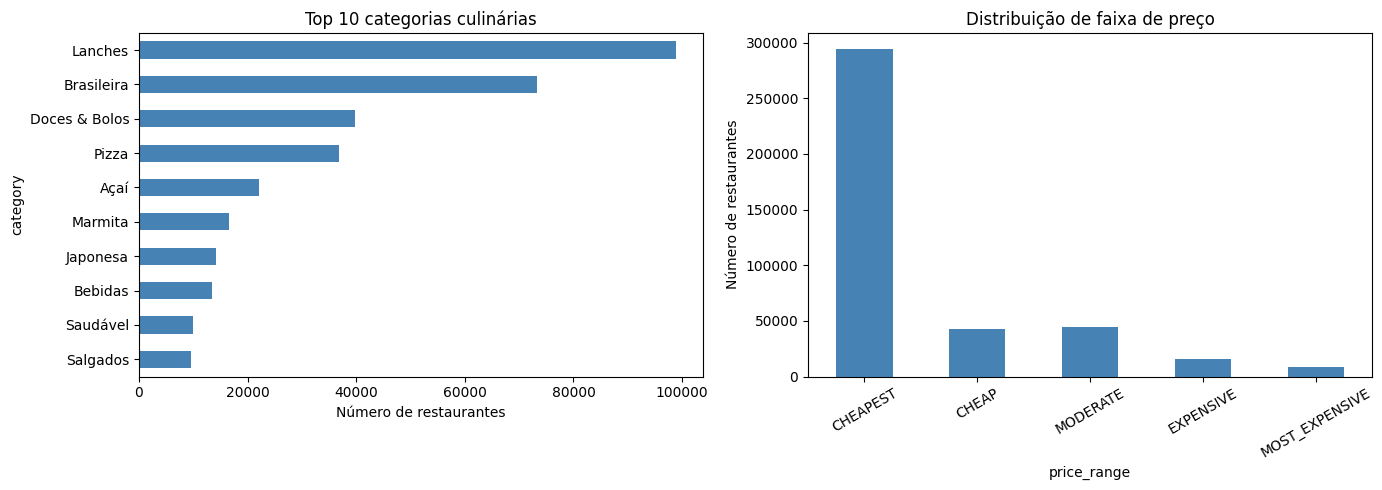

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 categorias
top_cat = df['category'].value_counts().head(10)
top_cat.plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 categorias culinárias')
axes[0].set_xlabel('Número de restaurantes')
axes[0].invert_yaxis()

# Price range
order = ['CHEAPEST', 'CHEAP', 'MODERATE', 'EXPENSIVE', 'MOST_EXPENSIVE']
price_counts = df['price_range'].value_counts().reindex(order)
price_counts.plot.bar(ax=axes[1], color='steelblue', rot=30)
axes[1].set_title('Distribuição de faixa de preço')
axes[1].set_ylabel('Número de restaurantes')

plt.tight_layout()
plt.show()

In [ ]:
print("Total de categorias únicas:", df['category'].nunique())
print("Total de municípios únicos (ibge):", df['ibge'].nunique())
print()
print("Restaurantes com agendamento disponível:",
      f"{df['availableForScheduling'].sum():,} ({df['availableForScheduling'].mean()*100:.1f}%)")

Total de categorias únicas: 61
Total de municípios únicos (ibge): 1478

Restaurantes com agendamento disponível: 1,697 (0.4%)


## 6. Detecção e Remoção de Outliers

Vamos visualizar a distribuição das variáveis numéricas com boxplots para identificar outliers.

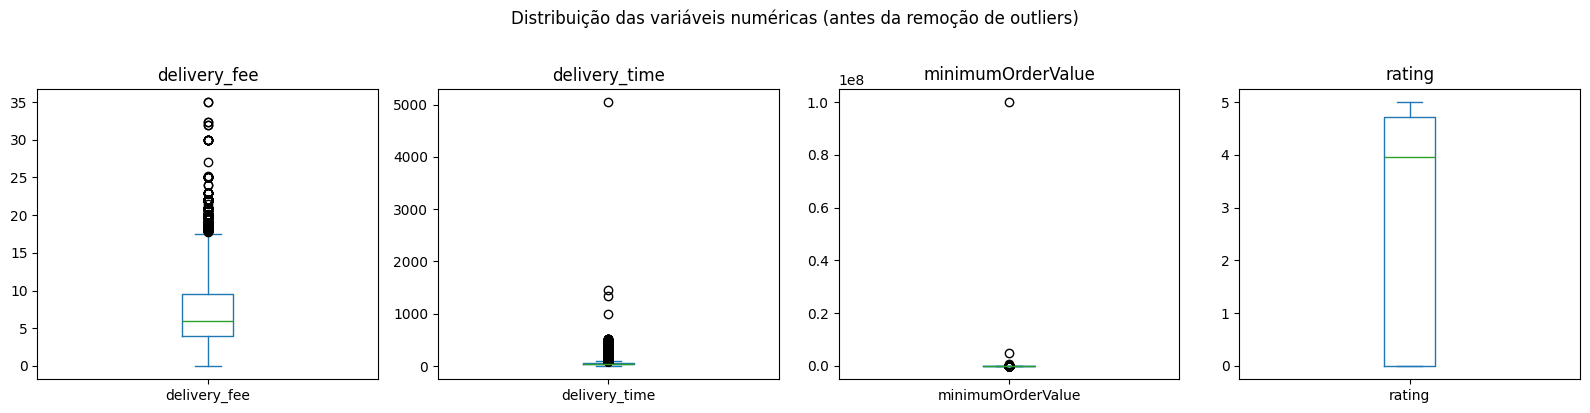

In [ ]:
colunas_numericas = ['delivery_fee', 'delivery_time', 'minimumOrderValue', 'rating']

fig, axes = plt.subplots(1, len(colunas_numericas), figsize=(16, 4))
fig.suptitle('Distribuição das variáveis numéricas (antes da remoção de outliers)', y=1.02)

for ax, col in zip(axes, colunas_numericas):
    df[col].plot.box(ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

Usamos o método IQR para identificar os outliers. A função `mapear_outliers` do `utils.py` calcula os limites inferior e superior para cada coluna numérica usando a regra dos 1,5×IQR:

In [ ]:
df_num = df[colunas_numericas].copy()

outliers_info = mapear_outliers(df_num)

print("Outliers detectados por coluna (método IQR — 1,5×IQR):")
print(f"{'Coluna':<22} {'Limite Inf':>12} {'Limite Sup':>12} {'Outliers':>10} {'% do total':>12}")
print("-" * 72)
for col, info in outliers_info.items():
    pct = info['outlier_count'] / len(df) * 100
    print(f"{col:<22} {info['lwr_bound']:>12.2f} {info['upr_bound']:>12.2f} {info['outlier_count']:>10,} {pct:>11.2f}%")

Outliers detectados por coluna (método IQR — 1,5×IQR):
Coluna                   Limite Inf   Limite Sup   Outliers   % do total
------------------------------------------------------------------------
delivery_fee                  -4.23        17.73      2,023        0.50%
delivery_time                 -2.50        97.50      3,857        0.95%
minimumOrderValue             -5.00        35.00      7,309        1.80%
rating                        -7.08        11.80          0        0.00%


In [ ]:
# Coletamos todos os índices que são outliers em pelo menos uma coluna numérica
outlier_indices = set()
for col, info in outliers_info.items():
    outlier_indices.update(info['outlier_idx'])

n_antes = len(df)
df_clean = df.drop(index=list(outlier_indices))
n_removidos = n_antes - len(df_clean)

print(f"Outliers removidos: {n_removidos:,} ({n_removidos/n_antes*100:.2f}% do dataset)")
print(f"Registros restantes: {len(df_clean):,}")

Outliers removidos: 12,135 (2.99% do dataset)
Registros restantes: 394,192


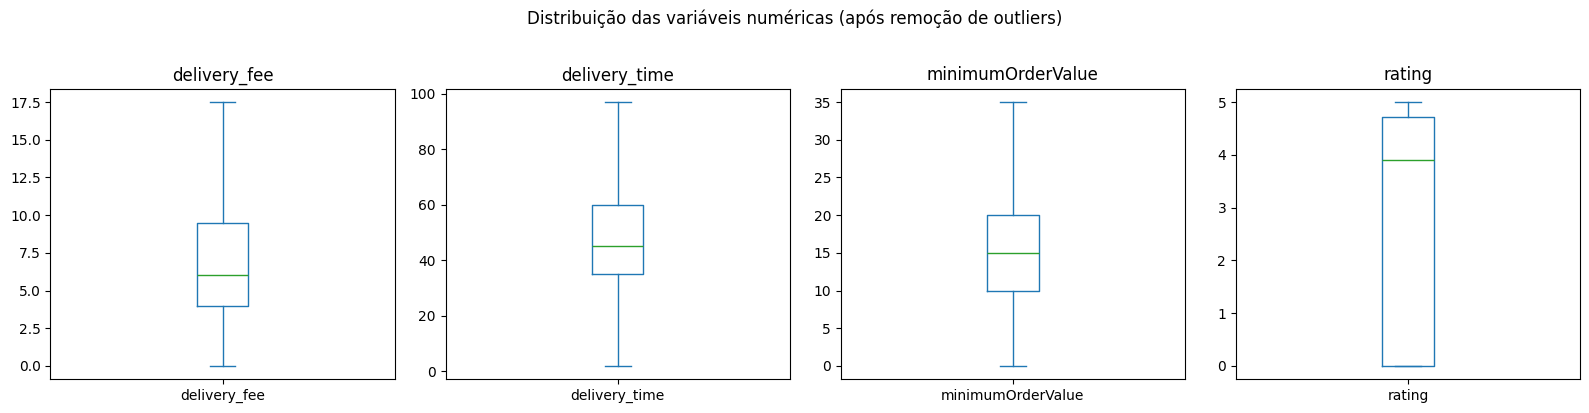

In [ ]:
fig, axes = plt.subplots(1, len(colunas_numericas), figsize=(16, 4))
fig.suptitle('Distribuição das variáveis numéricas (após remoção de outliers)', y=1.02)

for ax, col in zip(axes, colunas_numericas):
    df_clean[col].plot.box(ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

## 7. Normalização e Padronização

Os algoritmos de clustering que vamos usar na Etapa 3 (K-Means, DBSCAN) são sensíveis à escala das variáveis. Por isso precisamos normalizar os dados numéricos antes de calcular distâncias.

---

### MinMaxScaler vs StandardScaler — qual usar?

**MinMaxScaler** transforma os valores para ficarem entre 0 e 1, mantendo a distribuição original:

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

É uma boa escolha quando você sabe que os dados têm limites naturais e não há outliers que "puxem" a escala. O problema é que um único valor muito alto ou baixo já distorce toda a normalização — por exemplo, se o maior `delivery_time` for 180 minutos, ele vira 1.0, mas todos os outros ficam comprimidos no começo da escala.

**StandardScaler** (padronização Z-score) centraliza os dados na média 0 com desvio padrão 1:

$$x_{std} = \frac{x - \mu}{\sigma}$$

Funciona melhor quando os dados têm distribuições com caudas ou quando o algoritmo posterior é sensível a distribuições assimétricas. É mais robusto com relação a outliers residuais.

**Neste projeto**, as variáveis numéricas têm unidades muito diferentes entre si (reais, minutos, escala 0–5). Para que nenhuma variável domine as distâncias só por ter uma escala maior, vamos usar o **StandardScaler** como método padrão para as próximas etapas. Ainda assim, vamos visualizar os dois para comparar.

---

In [ ]:
df_num_clean = df_clean[colunas_numericas].copy()

scaler_mm = MinMaxScaler()
df_minmax = pd.DataFrame(
    scaler_mm.fit_transform(df_num_clean),
    columns=colunas_numericas,
    index=df_num_clean.index
)

scaler_std = StandardScaler()
df_standard = pd.DataFrame(
    scaler_std.fit_transform(df_num_clean),
    columns=colunas_numericas,
    index=df_num_clean.index
)

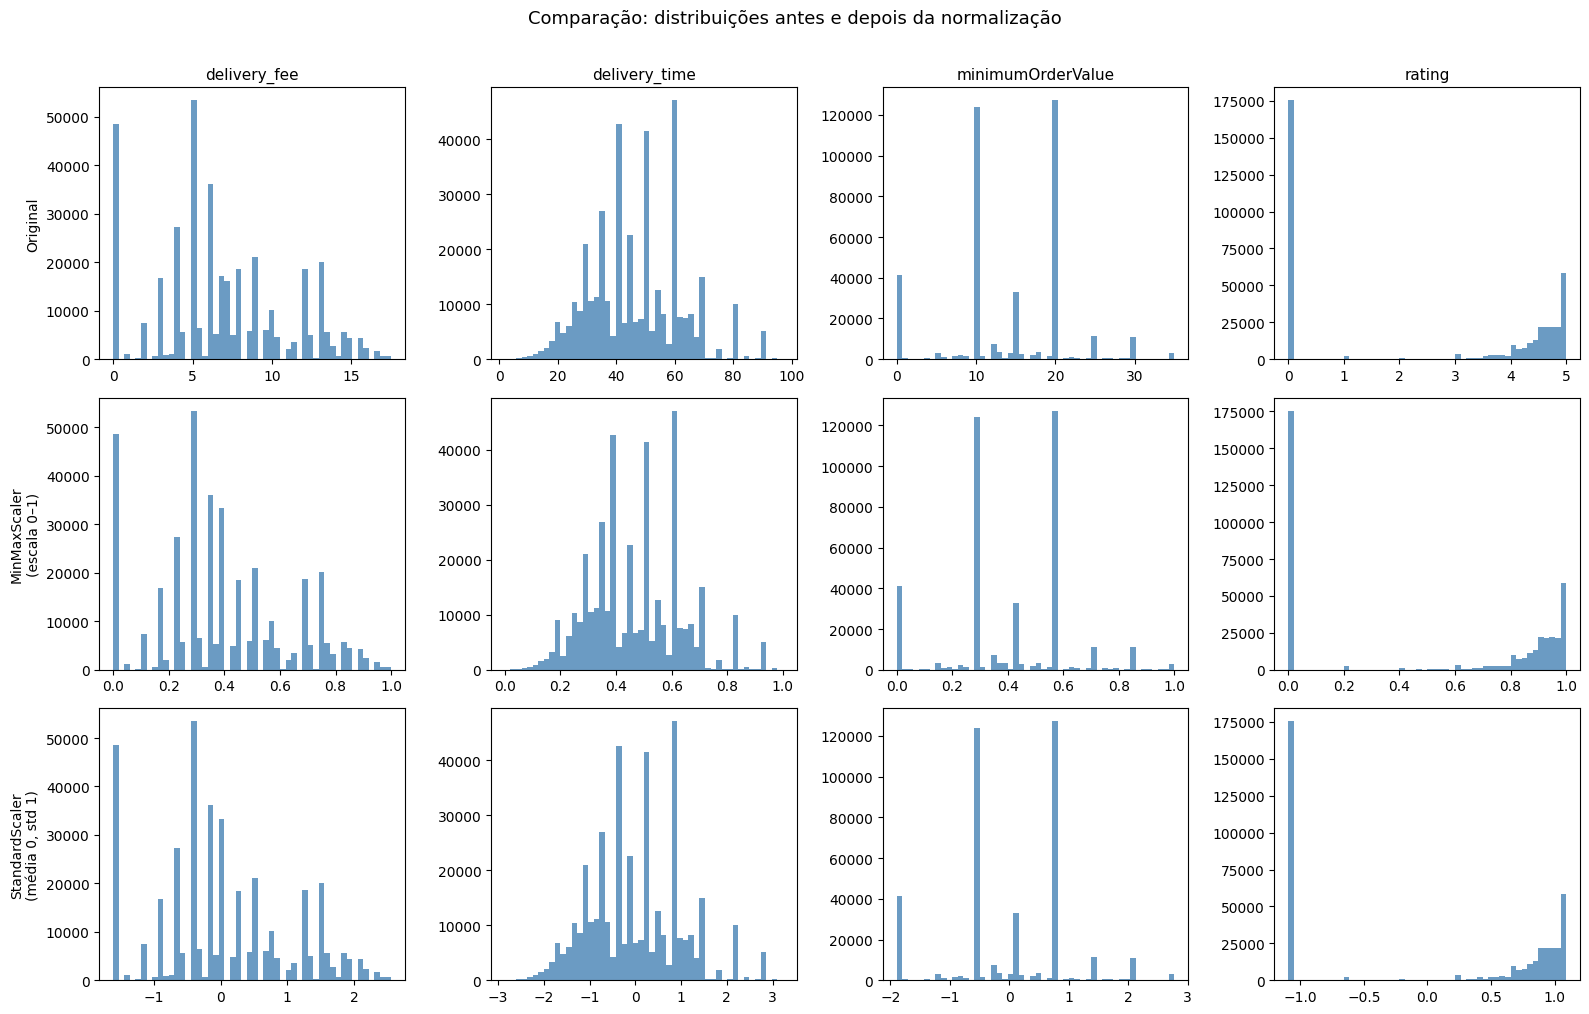

In [ ]:
# Comparação visual: original vs MinMax vs Standard
fig, axes = plt.subplots(3, len(colunas_numericas), figsize=(16, 10))
titulos_linhas = ['Original', 'MinMaxScaler\n(escala 0–1)', 'StandardScaler\n(média 0, std 1)']
dfs_plot = [df_num_clean, df_minmax, df_standard]

for i, (df_plot, titulo) in enumerate(zip(dfs_plot, titulos_linhas)):
    for j, col in enumerate(colunas_numericas):
        axes[i, j].hist(df_plot[col], bins=50, color='steelblue', edgecolor='none', alpha=0.8)
        if i == 0:
            axes[i, j].set_title(col, fontsize=11)
        if j == 0:
            axes[i, j].set_ylabel(titulo, fontsize=10)

plt.suptitle('Comparação: distribuições antes e depois da normalização', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
print("Estatísticas — MinMaxScaler:")
print(df_minmax.describe().round(3))
print()
print("Estatísticas — StandardScaler:")
print(df_standard.describe().round(3))

Estatísticas — MinMaxScaler:
       delivery_fee  delivery_time  minimumOrderValue      rating
count    394192.000     394192.000         394192.000  394192.000
mean          0.386          0.469              0.406       0.501
std           0.240          0.165              0.214       0.458
min           0.000          0.000              0.000       0.000
25%           0.229          0.347              0.286       0.000
50%           0.343          0.453              0.429       0.782
75%           0.542          0.611              0.571       0.943
max           1.000          1.000              1.000       1.000

Estatísticas — StandardScaler:
       delivery_fee  delivery_time  minimumOrderValue      rating
count    394192.000     394192.000         394192.000  394192.000
mean          0.000          0.000              0.000       0.000
std           1.000          1.000              1.000       1.000
min          -1.608         -2.849             -1.898      -1.094
25%          -0

Como esperado:
- **MinMaxScaler**: todos os valores ficam entre 0 e 1, mínimo ≈ 0, máximo ≈ 1.
- **StandardScaler**: média ≈ 0, desvio padrão ≈ 1 para todas as colunas.

Para as próximas etapas, vamos usar o **StandardScaler**.

## 8. Dataset Pré-processado Final

Montamos o dataset final combinando as colunas categóricas (sem normalização) com as numéricas padronizadas:

In [ ]:
colunas_categoricas = ['category', 'price_range', 'availableForScheduling', 'ibge']

df_preprocessed = pd.concat(
    [df_clean[colunas_categoricas].reset_index(drop=True),
     df_standard.reset_index(drop=True)],
    axis=1
)

print(f"Dataset final: {df_preprocessed.shape[0]:,} restaurantes × {df_preprocessed.shape[1]} atributos")
df_preprocessed.head()

Dataset final: 394,192 restaurantes × 8 atributos


,category,price_range,availableForScheduling,ibge,delivery_fee,delivery_time,minimumOrderValue,rating
0,Marmita,CHEAPEST,0,5300108,-0.659290,-1.251447,-0.562502,-1.094339
1,Açaí,CHEAPEST,0,5300108,0.292185,0.921866,-0.562502,-1.094339
2,Bebidas,MODERATE,0,5300108,1.243660,1.497155,-1.230091,-1.094339
3,Carnes,CHEAPEST,0,5300108,2.314070,1.049708,0.772676,-1.094339
4,Brasileira,CHEAPEST,0,5300108,1.243660,0.730104,0.772676,-1.094339


In [ ]:
nulos = df_preprocessed.isnull().sum().sum()
print(f"Valores nulos no dataset final: {nulos}")
assert nulos == 0, "Ainda há valores nulos no dataset!"
print()
print("Estatísticas das colunas numéricas normalizadas:")
df_preprocessed[colunas_numericas].describe().round(3)

Valores nulos no dataset final: 0

Estatísticas das colunas numéricas normalizadas:


,delivery_fee,delivery_time,minimumOrderValue,rating
count,394192.000,394192.000,394192.000,394192.000
mean,0.000,0.000,0.000,0.000
std,1.000,1.000,1.000,1.000
min,-1.608,-2.849,-1.898,-1.094
25%,-0.657,-0.740,-0.563,-1.094
50%,-0.181,-0.101,0.105,0.614
75%,0.649,0.858,0.773,0.967
max,2.554,3.223,2.775,1.090


In [ ]:
output_path = Path('data/processed')
output_path.mkdir(parents=True, exist_ok=True)

df_preprocessed.to_csv(output_path / 'restaurants_preprocessed.csv', index=False)
print(f"Dataset salvo em: {output_path / 'restaurants_preprocessed.csv'}")

Dataset salvo em: data\processed\restaurants_preprocessed.csv


## 9. Resumo das Decisões

| Etapa | Decisão | Impacto |
|---|---|---|
| Remoção de colunas | Removemos `avatar`, `url`, `name`, `tags`, `paymentCodes`, `distance` | Ficamos com 8 atributos analiticamente relevantes |
| Valores inválidos | Removemos registros com `delivery_time` ≤ 0 | 72 registros removidos |
| Outliers (IQR) | Removemos registros fora dos limites 1,5×IQR nas variáveis numéricas | Ver saída da célula de outliers acima |
| Normalização | Usamos **StandardScaler** nas colunas numéricas | Cada variável com média ≈ 0 e std ≈ 1 |
| Rating = 0 | **Mantivemos** — 44% dos restaurantes não têm avaliação ainda | É informação válida da plataforma |